In [446]:
print("AeroPure kernel is working!")

AeroPure kernel is working!


In [447]:
# ============================================================
# W4 CELL 1 — IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge, Lasso, LogisticRegression
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("W4 libraries imported successfully.")

W4 libraries imported successfully.


In [448]:
# ============================================================
# W4 CELL 2 — LOAD DATASET
# ============================================================

df = pd.read_csv(
    "../dataset kaggle/city_day.csv"
)

df["Date"] = pd.to_datetime(df["Date"])

df = df.sort_values(
    ["City", "Date"]
).reset_index(drop=True)

print("=" * 70)
print("W4 DATASET")
print("=" * 70)

print("Shape:", df.shape)

display(
    df[
        ["City", "Date", "AQI", "AQI_Bucket"]
    ].head()
)

W4 DATASET
Shape: (29531, 16)


,City,Date,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN


In [449]:
# ============================================================
# W4 CELL 3 — CREATE TOMORROW AQI
# ============================================================

df["Tomorrow_AQI"] = (
    df.groupby("City")["AQI"].shift(-1)
)

df["Next_Date"] = (
    df.groupby("City")["Date"].shift(-1)
)

df["Days_To_Next"] = (
    df["Next_Date"] - df["Date"]
).dt.days

print("=" * 70)
print("TOMORROW AQI TARGET")
print("=" * 70)

print(
    "Rows with next-day record:",
    (df["Days_To_Next"] == 1).sum()
)

print(
    "Missing Tomorrow_AQI:",
    df["Tomorrow_AQI"].isna().sum()
)

TOMORROW AQI TARGET
Rows with next-day record: 29505
Missing Tomorrow_AQI: 4682


In [450]:
# ============================================================
# W4 CELL 4 — CLEAN TOMORROW AQI
# ============================================================

df = df[
    df["Days_To_Next"] == 1
].copy()

df = df.dropna(
    subset=["Tomorrow_AQI"]
).copy()

df = df.drop(
    columns=[
        "Next_Date",
        "Days_To_Next"
    ]
)

df = df.reset_index(drop=True)

print("=" * 70)
print("CLEAN TOMORROW AQI DATA")
print("=" * 70)

print("Rows:", len(df))

print(
    "Missing Tomorrow_AQI:",
    df["Tomorrow_AQI"].isna().sum()
)

display(
    df[
        ["City", "Date", "AQI", "Tomorrow_AQI"]
    ].head(10)
)

CLEAN TOMORROW AQI DATA
Rows: 24849
Missing Tomorrow_AQI: 0


,City,Date,AQI,Tomorrow_AQI
0,Ahmedabad,2015-01-28,NaN,209.0
1,Ahmedabad,2015-01-29,209.0,328.0
2,Ahmedabad,2015-01-30,328.0,514.0
3,Ahmedabad,2015-01-31,514.0,782.0
4,Ahmedabad,2015-02-01,782.0,914.0
5,Ahmedabad,2015-02-02,914.0,660.0
6,Ahmedabad,2015-02-03,660.0,294.0
7,Ahmedabad,2015-02-04,294.0,149.0
8,Ahmedabad,2015-02-05,149.0,190.0
9,Ahmedabad,2015-02-06,190.0,247.0


In [451]:
# ============================================================
# W4 CELL 5 — FEATURES
# ============================================================

features = [
    "PM2.5",
    "PM10",
    "NO",
    "NO2",
    "NOx",
    "NH3",
    "CO",
    "SO2",
    "O3",
    "Benzene",
    "Toluene"
]

target = "Tomorrow_AQI"

print("=" * 70)
print("W4 FEATURES")
print("=" * 70)

print("Number of features:", len(features))

for feature in features:
    print("-", feature)

print("\nTarget:", target)

W4 FEATURES
Number of features: 11
- PM2.5
- PM10
- NO
- NO2
- NOx
- NH3
- CO
- SO2
- O3
- Benzene
- Toluene

Target: Tomorrow_AQI


In [452]:
# ============================================================
# W4 CELL 6 — TIME-BASED TRAIN / TEST SPLIT
# ============================================================

df = df.sort_values(
    ["Date", "City"]
).reset_index(drop=True)

unique_dates = sorted(
    df["Date"].unique()
)

split_index = int(
    len(unique_dates) * 0.80
)

split_date = unique_dates[split_index]

train_df = df[
    df["Date"] < split_date
].copy()

test_df = df[
    df["Date"] >= split_date
].copy()

print("=" * 70)
print("W4 TIME-BASED SPLIT")
print("=" * 70)

print("Split date:", split_date)

print("\nTotal rows:", len(df))
print("Train rows:", len(train_df))
print("Test rows :", len(test_df))

print("\nTraining period:")
print(
    train_df["Date"].min(),
    "to",
    train_df["Date"].max()
)

print("\nTesting period:")
print(
    test_df["Date"].min(),
    "to",
    test_df["Date"].max()
)

common_dates = set(
    train_df["Date"]
).intersection(
    set(test_df["Date"])
)

print("\nCommon dates:", len(common_dates))

W4 TIME-BASED SPLIT
Split date: 2019-05-26 00:00:00

Total rows: 24849
Train rows: 16017
Test rows : 8832

Training period:
2015-01-01 00:00:00 to 2019-05-25 00:00:00

Testing period:
2019-05-26 00:00:00 to 2020-06-30 00:00:00

Common dates: 0


In [453]:
# ============================================================
# W4 CELL 7 — MISSING VALUE IMPUTATION
# ============================================================

train_imp = train_df.copy()
test_imp = test_df.copy()

for col in features:

    # Calculate city median from TRAINING DATA ONLY
    city_medians = (
        train_imp
        .groupby("City")[col]
        .median()
    )

    # Overall training median
    overall_median = train_imp[col].median()

    # Training data
    train_imp[col] = (
        train_imp[col]
        .fillna(
            train_imp["City"].map(city_medians)
        )
        .fillna(overall_median)
    )

    # Test data uses training-derived medians
    test_imp[col] = (
        test_imp[col]
        .fillna(
            test_imp["City"].map(city_medians)
        )
        .fillna(overall_median)
    )

print("=" * 70)
print("W4 IMPUTATION")
print("=" * 70)

print("\nTRAIN missing values:")
print(train_imp[features].isna().sum())

print("\nTEST missing values:")
print(test_imp[features].isna().sum())

W4 IMPUTATION

TRAIN missing values:
PM2.5      0
PM10       0
NO         0
NO2        0
NOx        0
NH3        0
CO         0
SO2        0
O3         0
Benzene    0
Toluene    0
dtype: int64

TEST missing values:
PM2.5      0
PM10       0
NO         0
NO2        0
NOx        0
NH3        0
CO         0
SO2        0
O3         0
Benzene    0
Toluene    0
dtype: int64


In [454]:
# ============================================================
# W4 CELL 8 — CREATE X AND Y
# ============================================================

X_train = train_imp[features].copy()
X_test = test_imp[features].copy()

y_train = train_imp[target].copy()
y_test = test_imp[target].copy()

print("=" * 70)
print("W4 ML DATASET")
print("=" * 70)

print("\nX_train:", X_train.shape)
print("X_test :", X_test.shape)

print("\ny_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\nMissing target values:")
print("y_train:", y_train.isna().sum())
print("y_test :", y_test.isna().sum())

W4 ML DATASET

X_train: (16017, 11)
X_test : (8832, 11)

y_train: (16017,)
y_test : (8832,)

Missing target values:
y_train: 0
y_test : 0


In [455]:
# ============================================================
# W4 CELL 9 — STANDARDIZATION
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

print("=" * 70)
print("STANDARDIZATION COMPLETE")
print("=" * 70)

print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled :", X_test_scaled.shape)

STANDARDIZATION COMPLETE
X_train_scaled: (16017, 11)
X_test_scaled : (8832, 11)


In [456]:
# ============================================================
# W4 CELL 10 — RIDGE REGRESSION
# ============================================================

ridge_model = Ridge(
    alpha=1.0
)

ridge_model.fit(
    X_train_scaled,
    y_train
)

y_pred_ridge = ridge_model.predict(
    X_test_scaled
)

print("=" * 70)
print("RIDGE REGRESSION")
print("=" * 70)

print("Alpha:", 1.0)
print("Predictions generated:", len(y_pred_ridge))

RIDGE REGRESSION
Alpha: 1.0
Predictions generated: 8832


In [457]:
# ============================================================
# W4 CELL 11 — RIDGE EVALUATION
# ============================================================

ridge_mae = mean_absolute_error(
    y_test,
    y_pred_ridge
)

ridge_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_ridge
    )
)

ridge_r2 = r2_score(
    y_test,
    y_pred_ridge
)

print("=" * 70)
print("RIDGE MODEL PERFORMANCE")
print("=" * 70)

print(f"MAE  : {ridge_mae:.4f}")
print(f"RMSE : {ridge_rmse:.4f}")
print(f"R²   : {ridge_r2:.4f}")

RIDGE MODEL PERFORMANCE
MAE  : 25.6951
RMSE : 42.4745
R²   : 0.8331


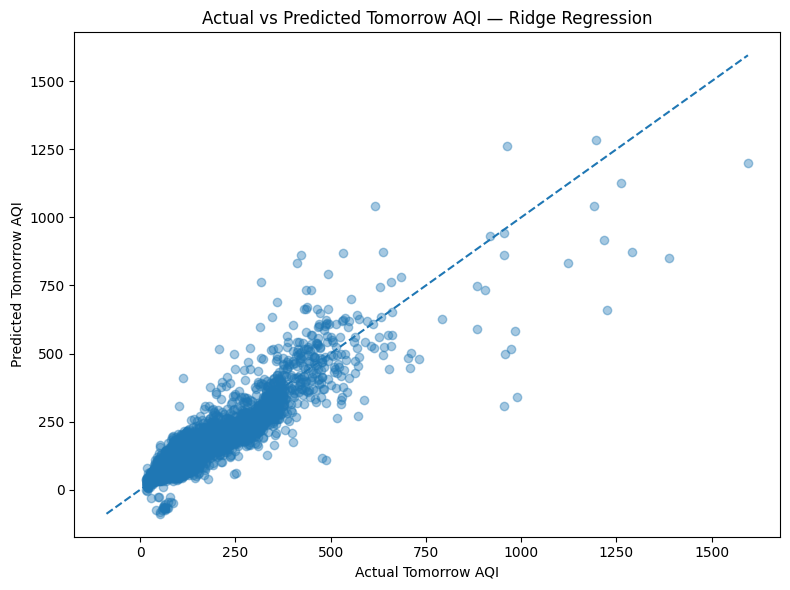

Ridge graph saved successfully.


In [458]:
# ============================================================
# W4 CELL 12 — RIDGE ACTUAL VS PREDICTED
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_ridge,
    alpha=0.4
)

min_value = min(
    y_test.min(),
    y_pred_ridge.min()
)

max_value = max(
    y_test.max(),
    y_pred_ridge.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Tomorrow AQI")
plt.ylabel("Predicted Tomorrow AQI")

plt.title(
    "Actual vs Predicted Tomorrow AQI — Ridge Regression"
)

plt.tight_layout()

plt.savefig(
    "../graphs/w4_ridge_actual_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Ridge graph saved successfully.")

In [459]:
# ============================================================
# W4 CELL 13 — LASSO REGRESSION
# ============================================================

lasso_model = Lasso(
    alpha=0.01,
    max_iter=10000
)

lasso_model.fit(
    X_train_scaled,
    y_train
)

y_pred_lasso = lasso_model.predict(
    X_test_scaled
)

print("=" * 70)
print("LASSO REGRESSION")
print("=" * 70)

print("Alpha:", 0.01)
print("Predictions generated:", len(y_pred_lasso))

LASSO REGRESSION
Alpha: 0.01
Predictions generated: 8832


In [460]:
# ============================================================
# W4 CELL 14 — LASSO EVALUATION
# ============================================================

lasso_mae = mean_absolute_error(
    y_test,
    y_pred_lasso
)

lasso_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_lasso
    )
)

lasso_r2 = r2_score(
    y_test,
    y_pred_lasso
)

print("=" * 70)
print("LASSO MODEL PERFORMANCE")
print("=" * 70)

print(f"MAE  : {lasso_mae:.4f}")
print(f"RMSE : {lasso_rmse:.4f}")
print(f"R²   : {lasso_r2:.4f}")

LASSO MODEL PERFORMANCE
MAE  : 25.6884
RMSE : 42.4599
R²   : 0.8332


In [461]:
# ============================================================
# W4 CELL 15 — OLS BASELINE FOR COMPARISON
# ============================================================

from sklearn.linear_model import LinearRegression

# Create OLS model
ols_model_w4 = LinearRegression()

# Train OLS using the same W4 training data
ols_model_w4.fit(
    X_train_scaled,
    y_train
)

# Predict on the same W4 test data
y_pred_ols_w4 = ols_model_w4.predict(
    X_test_scaled
)

# Calculate metrics
ols_mae_w4 = mean_absolute_error(
    y_test,
    y_pred_ols_w4
)

ols_rmse_w4 = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_ols_w4
    )
)

ols_r2_w4 = r2_score(
    y_test,
    y_pred_ols_w4
)

print("=" * 70)
print("W4 OLS BASELINE")
print("=" * 70)

print(f"MAE  : {ols_mae_w4:.4f}")
print(f"RMSE : {ols_rmse_w4:.4f}")
print(f"R²   : {ols_r2_w4:.4f}")

W4 OLS BASELINE
MAE  : 25.6947
RMSE : 42.4752
R²   : 0.8331


In [462]:
# ============================================================
# W4 CELL 16 — OLS VS RIDGE VS LASSO
# ============================================================

regression_comparison = pd.DataFrame({
    "Model": [
        "OLS Linear Regression",
        "Ridge Regression",
        "Lasso Regression"
    ],
    "MAE": [
        ols_mae_w4,
        ridge_mae,
        lasso_mae
    ],
    "RMSE": [
        ols_rmse_w4,
        ridge_rmse,
        lasso_rmse
    ],
    "R2": [
        ols_r2_w4,
        ridge_r2,
        lasso_r2
    ]
})

print("=" * 70)
print("W4 REGRESSION MODEL COMPARISON")
print("=" * 70)

display(regression_comparison)

W4 REGRESSION MODEL COMPARISON


,Model,MAE,RMSE,R2
0,OLS Linear Regression,25.694745,42.475218,0.833065
1,Ridge Regression,25.695081,42.474451,0.833072
2,Lasso Regression,25.688423,42.459937,0.833186


In [463]:
# ============================================================
# W4 CELL 17 — SAVE REGRESSION COMPARISON
# ============================================================

regression_comparison.to_csv(
    "../graphs/w4_regression_comparison.csv",
    index=False
)

print("W4 regression comparison saved successfully.")

W4 regression comparison saved successfully.


In [464]:
# ============================================================
# W4 CELL 18 — HAZARDOUS-AIR-DAY TARGET
# ============================================================

HAZARDOUS_THRESHOLD = 301

train_imp["Hazardous_Tomorrow"] = (
    train_imp["Tomorrow_AQI"] >= HAZARDOUS_THRESHOLD
).astype(int)

test_imp["Hazardous_Tomorrow"] = (
    test_imp["Tomorrow_AQI"] >= HAZARDOUS_THRESHOLD
).astype(int)

y_train_cls = train_imp[
    "Hazardous_Tomorrow"
].copy()

y_test_cls = test_imp[
    "Hazardous_Tomorrow"
].copy()

print("=" * 70)
print("HAZARDOUS-AIR-DAY TARGET")
print("=" * 70)

print("Hazardous threshold:", HAZARDOUS_THRESHOLD)

print("\nTRAIN CLASS DISTRIBUTION:")
print(
    y_train_cls.value_counts()
    .sort_index()
)

print("\nTEST CLASS DISTRIBUTION:")
print(
    y_test_cls.value_counts()
    .sort_index()
)

print("\nTRAIN CLASS PERCENTAGES:")
print(
    (y_train_cls.value_counts(normalize=True)
     .sort_index() * 100)
)

HAZARDOUS-AIR-DAY TARGET
Hazardous threshold: 301

TRAIN CLASS DISTRIBUTION:
Hazardous_Tomorrow
0    12949
1     3068
Name: count, dtype: int64

TEST CLASS DISTRIBUTION:
Hazardous_Tomorrow
0    8226
1     606
Name: count, dtype: int64

TRAIN CLASS PERCENTAGES:
Hazardous_Tomorrow
0    80.845352
1    19.154648
Name: proportion, dtype: float64


In [465]:
# ============================================================
# W4 CELL 19 — CLASS BALANCE
# ============================================================

train_class_counts = (
    y_train_cls
    .value_counts()
    .sort_index()
)

test_class_counts = (
    y_test_cls
    .value_counts()
    .sort_index()
)

print("=" * 70)
print("CLASS BALANCE")
print("=" * 70)

print("\nTRAIN:")
print(
    "Non-Hazardous (0):",
    train_class_counts.get(0, 0)
)

print(
    "Hazardous (1):",
    train_class_counts.get(1, 0)
)

print("\nTEST:")
print(
    "Non-Hazardous (0):",
    test_class_counts.get(0, 0)
)

print(
    "Hazardous (1):",
    test_class_counts.get(1, 0)
)

CLASS BALANCE

TRAIN:
Non-Hazardous (0): 12949
Hazardous (1): 3068

TEST:
Non-Hazardous (0): 8226
Hazardous (1): 606


In [466]:
# ============================================================
# W4 CELL 20 — LOGISTIC REGRESSION CLASSIFIER
# ============================================================

logistic_model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

logistic_model.fit(
    X_train_scaled,
    y_train_cls
)

# Predicted class
y_pred_cls = logistic_model.predict(
    X_test_scaled
)

# Predicted probability of hazardous class
y_prob_cls = logistic_model.predict_proba(
    X_test_scaled
)[:, 1]

print("=" * 70)
print("LOGISTIC REGRESSION CLASSIFIER")
print("=" * 70)

print("Model trained successfully.")
print("Test predictions:", len(y_pred_cls))

LOGISTIC REGRESSION CLASSIFIER
Model trained successfully.
Test predictions: 8832


In [467]:
# ============================================================
# W4 CELL 21 — CLASSIFICATION EVALUATION
# ============================================================

accuracy = accuracy_score(
    y_test_cls,
    y_pred_cls
)

precision = precision_score(
    y_test_cls,
    y_pred_cls,
    zero_division=0
)

recall = recall_score(
    y_test_cls,
    y_pred_cls,
    zero_division=0
)

f1 = f1_score(
    y_test_cls,
    y_pred_cls,
    zero_division=0
)

roc_auc = roc_auc_score(
    y_test_cls,
    y_prob_cls
)

print("=" * 70)
print("LOGISTIC REGRESSION PERFORMANCE")
print("=" * 70)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")

LOGISTIC REGRESSION PERFORMANCE
Accuracy  : 0.9691
Precision : 0.7063
Recall    : 0.9406
F1 Score  : 0.8068
ROC-AUC   : 0.9912


CONFUSION MATRIX
[[7989  237]
 [  36  570]]


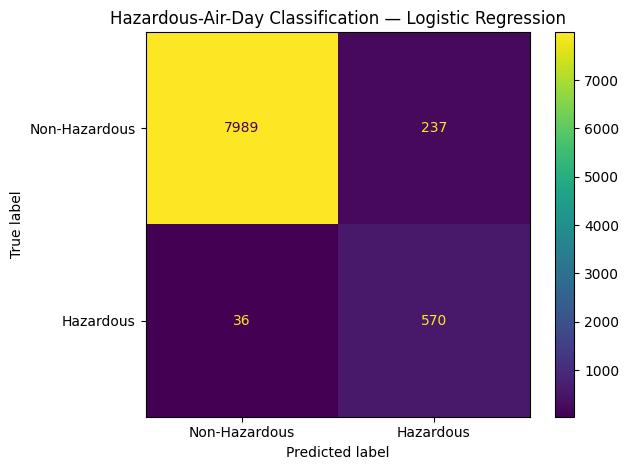

Confusion matrix saved successfully.


In [468]:
# ============================================================
# W4 CELL 22 — CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test_cls,
    y_pred_cls
)

print("=" * 70)
print("CONFUSION MATRIX")
print("=" * 70)

print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Non-Hazardous",
        "Hazardous"
    ]
)

disp.plot()

plt.title(
    "Hazardous-Air-Day Classification — Logistic Regression"
)

plt.tight_layout()

plt.savefig(
    "../graphs/w4_logistic_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Confusion matrix saved successfully.")

In [469]:
# ============================================================
# W4 CELL 23 — SAVE CLASSIFICATION RESULTS
# ============================================================

classification_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]
})

print("=" * 70)
print("HAZARDOUS-AIR-DAY RESULTS")
print("=" * 70)

display(classification_results)

classification_results.to_csv(
    "../graphs/w4_logistic_results.csv",
    index=False
)

print("Classification results saved successfully.")

HAZARDOUS-AIR-DAY RESULTS


,Metric,Score
0,Accuracy,0.969090
1,Precision,0.706320
2,Recall,0.940594
3,F1 Score,0.806794
4,ROC-AUC,0.991235


Classification results saved successfully.


In [470]:
# ============================================================
# W4 CELL 24 — FEATURE ENGINEERING
# ============================================================

# Work on a copy of the cleaned dataset
df_fe = df.copy()

# Sort chronologically within each city
df_fe = df_fe.sort_values(
    ["City", "Date"]
).reset_index(drop=True)

# ------------------------------------------------------------
# 1. Current AQI
# ------------------------------------------------------------

df_fe["AQI_Current"] = df_fe["AQI"]

# ------------------------------------------------------------
# 2. Previous-day AQI
# ------------------------------------------------------------

df_fe["AQI_Lag1"] = (
    df_fe.groupby("City")["AQI"]
    .shift(1)
)

# ------------------------------------------------------------
# 3. Three-day historical AQI average
#    Includes current day and previous 2 days
# ------------------------------------------------------------

df_fe["AQI_3Day_Mean"] = (
    df_fe.groupby("City")["AQI"]
    .transform(
        lambda x: x.rolling(
            window=3,
            min_periods=1
        ).mean()
    )
)

# ------------------------------------------------------------
# 4. Day of week
# Monday = 0, Sunday = 6
# ------------------------------------------------------------

df_fe["DayOfWeek"] = (
    df_fe["Date"].dt.dayofweek
)

# ------------------------------------------------------------
# 5. Month
# ------------------------------------------------------------

df_fe["Month"] = (
    df_fe["Date"].dt.month
)

print("=" * 70)
print("W4 FEATURE ENGINEERING")
print("=" * 70)

new_features = [
    "AQI_Current",
    "AQI_Lag1",
    "AQI_3Day_Mean",
    "DayOfWeek",
    "Month"
]

print("New engineered features:")

for feature in new_features:
    print("-", feature)

display(
    df_fe[
        [
            "City",
            "Date",
            "AQI",
            "Tomorrow_AQI",
            "AQI_Current",
            "AQI_Lag1",
            "AQI_3Day_Mean",
            "DayOfWeek",
            "Month"
        ]
    ].head(10)
)

W4 FEATURE ENGINEERING
New engineered features:
- AQI_Current
- AQI_Lag1
- AQI_3Day_Mean
- DayOfWeek
- Month


,City,Date,AQI,Tomorrow_AQI,AQI_Current,AQI_Lag1,AQI_3Day_Mean,DayOfWeek,Month
0,Ahmedabad,2015-01-28,NaN,209.0,NaN,NaN,NaN,2,1
1,Ahmedabad,2015-01-29,209.0,328.0,209.0,NaN,209.000000,3,1
2,Ahmedabad,2015-01-30,328.0,514.0,328.0,209.0,268.500000,4,1
3,Ahmedabad,2015-01-31,514.0,782.0,514.0,328.0,350.333333,5,1
4,Ahmedabad,2015-02-01,782.0,914.0,782.0,514.0,541.333333,6,2
5,Ahmedabad,2015-02-02,914.0,660.0,914.0,782.0,736.666667,0,2
6,Ahmedabad,2015-02-03,660.0,294.0,660.0,914.0,785.333333,1,2
7,Ahmedabad,2015-02-04,294.0,149.0,294.0,660.0,622.666667,2,2
8,Ahmedabad,2015-02-05,149.0,190.0,149.0,294.0,367.666667,3,2
9,Ahmedabad,2015-02-06,190.0,247.0,190.0,149.0,211.000000,4,2


In [471]:
# ============================================================
# W4 CELL 25 — CHECK ENGINEERED FEATURES
# ============================================================

print("=" * 70)
print("ENGINEERED FEATURE MISSING VALUES")
print("=" * 70)

print(
    df_fe[
        new_features
    ].isna().sum()
)

print("\nRows before removing missing lag values:")
print(len(df_fe))

ENGINEERED FEATURE MISSING VALUES
AQI_Current      506
AQI_Lag1         532
AQI_3Day_Mean     30
DayOfWeek          0
Month              0
dtype: int64

Rows before removing missing lag values:
24849


In [472]:
# ============================================================
# W4 CELL 26 — TRAIN / TEST SPLIT WITH ENGINEERED FEATURES
# ============================================================

df_fe = df_fe.dropna(
    subset=["AQI_Lag1"]
).copy()

df_fe = df_fe.sort_values(
    ["Date", "City"]
).reset_index(drop=True)

unique_dates_fe = sorted(
    df_fe["Date"].unique()
)

split_index_fe = int(
    len(unique_dates_fe) * 0.80
)

split_date_fe = unique_dates_fe[
    split_index_fe
]

train_fe = df_fe[
    df_fe["Date"] < split_date_fe
].copy()

test_fe = df_fe[
    df_fe["Date"] >= split_date_fe
].copy()

print("=" * 70)
print("W4 FEATURE-ENGINEERED SPLIT")
print("=" * 70)

print("Split date:", split_date_fe)

print("Train rows:", len(train_fe))
print("Test rows :", len(test_fe))

print(
    "\nCommon dates:",
    len(
        set(train_fe["Date"])
        .intersection(set(test_fe["Date"]))
    )
)

W4 FEATURE-ENGINEERED SPLIT
Split date: 2019-05-26 00:00:00
Train rows: 15636
Test rows : 8681

Common dates: 0


In [473]:
# ============================================================
# W4 CELL 27 — FINAL ENGINEERED FEATURE SET
# ============================================================

pollutant_features = [
    "PM2.5",
    "PM10",
    "NO",
    "NO2",
    "NOx",
    "NH3",
    "CO",
    "SO2",
    "O3",
    "Benzene",
    "Toluene"
]

engineered_features = [
    "AQI_Current",
    "AQI_Lag1",
    "AQI_3Day_Mean",
    "DayOfWeek",
    "Month"
]

features_fe = (
    pollutant_features +
    engineered_features
)

print("=" * 70)
print("FINAL FEATURE SET")
print("=" * 70)

print("Pollutant features :", len(pollutant_features))
print("Engineered features:", len(engineered_features))
print("Total features     :", len(features_fe))

print("\nFeatures:")

for feature in features_fe:
    print("-", feature)

FINAL FEATURE SET
Pollutant features : 11
Engineered features: 5
Total features     : 16

Features:
- PM2.5
- PM10
- NO
- NO2
- NOx
- NH3
- CO
- SO2
- O3
- Benzene
- Toluene
- AQI_Current
- AQI_Lag1
- AQI_3Day_Mean
- DayOfWeek
- Month


In [474]:
# ============================================================
# W4 CELL 28 — IMPUTE ENGINEERED DATA
# ============================================================

train_fe_imp = train_fe.copy()
test_fe_imp = test_fe.copy()

for col in features_fe:

    # City median from training data only
    city_medians = (
        train_fe_imp
        .groupby("City")[col]
        .median()
    )

    # Overall training median
    overall_median = (
        train_fe_imp[col].median()
    )

    # Training
    train_fe_imp[col] = (
        train_fe_imp[col]
        .fillna(
            train_fe_imp["City"].map(
                city_medians
            )
        )
        .fillna(overall_median)
    )

    # Test
    test_fe_imp[col] = (
        test_fe_imp[col]
        .fillna(
            test_fe_imp["City"].map(
                city_medians
            )
        )
        .fillna(overall_median)
    )

print("=" * 70)
print("ENGINEERED DATA IMPUTATION")
print("=" * 70)

print(
    "Training missing values:",
    train_fe_imp[
        features_fe
    ].isna().sum().sum()
)

print(
    "Testing missing values:",
    test_fe_imp[
        features_fe
    ].isna().sum().sum()
)

ENGINEERED DATA IMPUTATION
Training missing values: 0
Testing missing values: 0


In [475]:
# ============================================================
# W4 CELL 29 — SCALE ENGINEERED FEATURES
# ============================================================

X_train_fe = train_fe_imp[
    features_fe
]

X_test_fe = test_fe_imp[
    features_fe
]

y_train_fe = train_fe_imp[
    "Tomorrow_AQI"
]

y_test_fe = test_fe_imp[
    "Tomorrow_AQI"
]

scaler_fe = StandardScaler()

X_train_fe_scaled = (
    scaler_fe.fit_transform(
        X_train_fe
    )
)

X_test_fe_scaled = (
    scaler_fe.transform(
        X_test_fe
    )
)

print("=" * 70)
print("ENGINEERED ML DATASET")
print("=" * 70)

print(
    "X_train:",
    X_train_fe_scaled.shape
)

print(
    "X_test :",
    X_test_fe_scaled.shape
)

print(
    "y_train:",
    y_train_fe.shape
)

print(
    "y_test :",
    y_test_fe.shape
)

ENGINEERED ML DATASET
X_train: (15636, 16)
X_test : (8681, 16)
y_train: (15636,)
y_test : (8681,)


In [476]:
# ============================================================
# W4 CELL 30 — FEATURE-ENGINEERED RIDGE
# ============================================================

ridge_fe = Ridge(
    alpha=1.0
)

ridge_fe.fit(
    X_train_fe_scaled,
    y_train_fe
)

y_pred_ridge_fe = ridge_fe.predict(
    X_test_fe_scaled
)

ridge_fe_mae = mean_absolute_error(
    y_test_fe,
    y_pred_ridge_fe
)

ridge_fe_rmse = np.sqrt(
    mean_squared_error(
        y_test_fe,
        y_pred_ridge_fe
    )
)

ridge_fe_r2 = r2_score(
    y_test_fe,
    y_pred_ridge_fe
)

print("=" * 70)
print("FEATURE-ENGINEERED RIDGE")
print("=" * 70)

print(f"MAE  : {ridge_fe_mae:.4f}")
print(f"RMSE : {ridge_fe_rmse:.4f}")
print(f"R²   : {ridge_fe_r2:.4f}")

FEATURE-ENGINEERED RIDGE
MAE  : 22.1350
RMSE : 40.7277
R²   : 0.8452


In [477]:
# ============================================================
# W4 CELL 31 — FEATURE-ENGINEERED LASSO
# ============================================================

lasso_fe = Lasso(
    alpha=0.01,
    max_iter=10000
)

lasso_fe.fit(
    X_train_fe_scaled,
    y_train_fe
)

y_pred_lasso_fe = lasso_fe.predict(
    X_test_fe_scaled
)

lasso_fe_mae = mean_absolute_error(
    y_test_fe,
    y_pred_lasso_fe
)

lasso_fe_rmse = np.sqrt(
    mean_squared_error(
        y_test_fe,
        y_pred_lasso_fe
    )
)

lasso_fe_r2 = r2_score(
    y_test_fe,
    y_pred_lasso_fe
)

print("=" * 70)
print("FEATURE-ENGINEERED LASSO")
print("=" * 70)

print(f"MAE  : {lasso_fe_mae:.4f}")
print(f"RMSE : {lasso_fe_rmse:.4f}")
print(f"R²   : {lasso_fe_r2:.4f}")

FEATURE-ENGINEERED LASSO
MAE  : 22.1285
RMSE : 40.7153
R²   : 0.8452


In [478]:
# ============================================================
# W4 CELL 32 — FEATURE ENGINEERING COMPARISON
# ============================================================

feature_comparison = pd.DataFrame({
    "Model": [
        "Original Lasso (11 features)",
        "Engineered Ridge (16 features)",
        "Engineered Lasso (16 features)"
    ],
    "MAE": [
        lasso_mae,
        ridge_fe_mae,
        lasso_fe_mae
    ],
    "RMSE": [
        lasso_rmse,
        ridge_fe_rmse,
        lasso_fe_rmse
    ],
    "R2": [
        lasso_r2,
        ridge_fe_r2,
        lasso_fe_r2
    ]
})

print("=" * 70)
print("FEATURE ENGINEERING MODEL COMPARISON")
print("=" * 70)

display(feature_comparison)

FEATURE ENGINEERING MODEL COMPARISON


,Model,MAE,RMSE,R2
0,Original Lasso (11 features),25.688423,42.459937,0.833186
1,Engineered Ridge (16 features),22.134959,40.727729,0.845156
2,Engineered Lasso (16 features),22.128465,40.715327,0.845250


In [479]:
# ============================================================
# W4 CELL 33 — SAVE FEATURE ENGINEERING RESULTS
# ============================================================

feature_comparison.to_csv(
    "../graphs/w4_feature_engineering_comparison.csv",
    index=False
)

print("Feature engineering comparison saved successfully.")

Feature engineering comparison saved successfully.


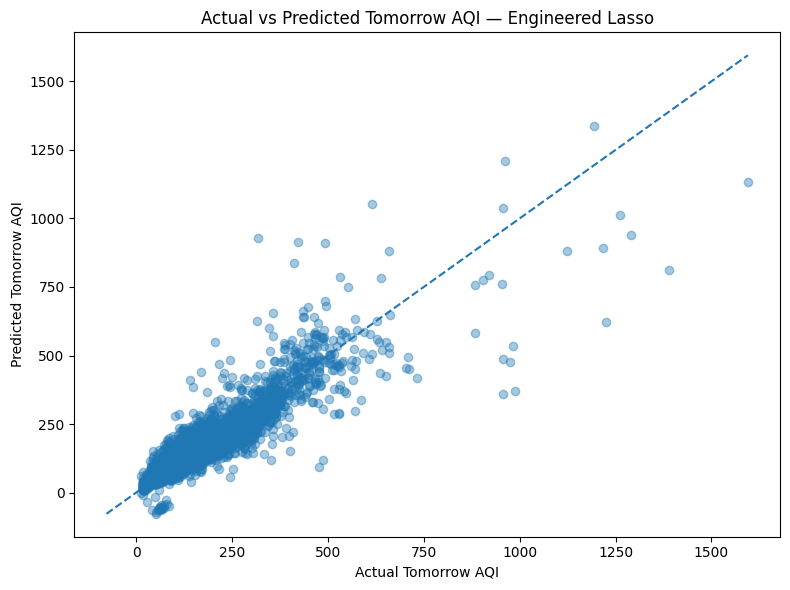

Best-model graph saved successfully.


In [480]:
# ============================================================
# W4 CELL 34 — BEST MODEL ACTUAL VS PREDICTED
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test_fe,
    y_pred_lasso_fe,
    alpha=0.4
)

min_value = min(
    y_test_fe.min(),
    y_pred_lasso_fe.min()
)

max_value = max(
    y_test_fe.max(),
    y_pred_lasso_fe.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Tomorrow AQI")
plt.ylabel("Predicted Tomorrow AQI")

plt.title(
    "Actual vs Predicted Tomorrow AQI — Engineered Lasso"
)

plt.tight_layout()

plt.savefig(
    "../graphs/w4_engineered_lasso_actual_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Best-model graph saved successfully.")

In [481]:
# ============================================================
# W4 CELL 35 — ENGINEERED LASSO RESIDUAL ANALYSIS
# ============================================================

lasso_fe_residuals = (
    y_test_fe.values - y_pred_lasso_fe
)

print("=" * 70)
print("ENGINEERED LASSO RESIDUAL ANALYSIS")
print("=" * 70)

print(
    f"Mean residual: {np.mean(lasso_fe_residuals):.4f}"
)

print(
    f"Std residual : {np.std(lasso_fe_residuals):.4f}"
)

print(
    f"Min residual : {np.min(lasso_fe_residuals):.4f}"
)

print(
    f"Max residual : {np.max(lasso_fe_residuals):.4f}"
)

ENGINEERED LASSO RESIDUAL ANALYSIS
Mean residual: -1.7506
Std residual : 40.6777
Min residual : -609.6782
Max residual : 615.5456


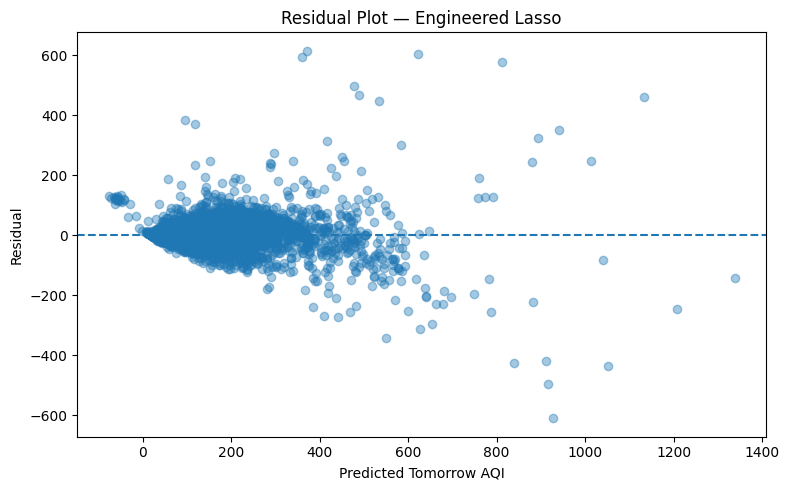

Residual graph saved successfully.


In [482]:
# ============================================================
# W4 CELL 36 — ENGINEERED LASSO RESIDUAL PLOT
# ============================================================

plt.figure(figsize=(8, 5))

plt.scatter(
    y_pred_lasso_fe,
    lasso_fe_residuals,
    alpha=0.4
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Predicted Tomorrow AQI")
plt.ylabel("Residual")

plt.title(
    "Residual Plot — Engineered Lasso"
)

plt.tight_layout()

plt.savefig(
    "../graphs/w4_engineered_lasso_residual_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Residual graph saved successfully.")

In [483]:
# ============================================================
# W4 CELL 37 — LASSO COEFFICIENT ANALYSIS
# ============================================================

coefficient_df = pd.DataFrame({
    "Feature": features_fe,
    "Coefficient": lasso_fe.coef_
})

coefficient_df["Absolute_Coefficient"] = (
    coefficient_df["Coefficient"].abs()
)

coefficient_df = coefficient_df.sort_values(
    "Absolute_Coefficient",
    ascending=False
).reset_index(drop=True)

print("=" * 70)
print("ENGINEERED LASSO COEFFICIENTS")
print("=" * 70)

display(coefficient_df)

ENGINEERED LASSO COEFFICIENTS


,Feature,Coefficient,Absolute_Coefficient
0,CO,54.114640,54.114640
1,AQI_3Day_Mean,50.191270,50.191270
2,PM2.5,43.075686,43.075686
3,AQI_Current,26.275007,26.275007
4,AQI_Lag1,-19.320732,19.320732
5,PM10,14.597702,14.597702
6,SO2,8.320678,8.320678
7,NO2,5.617038,5.617038
8,O3,4.108482,4.108482
9,NOx,3.125229,3.125229


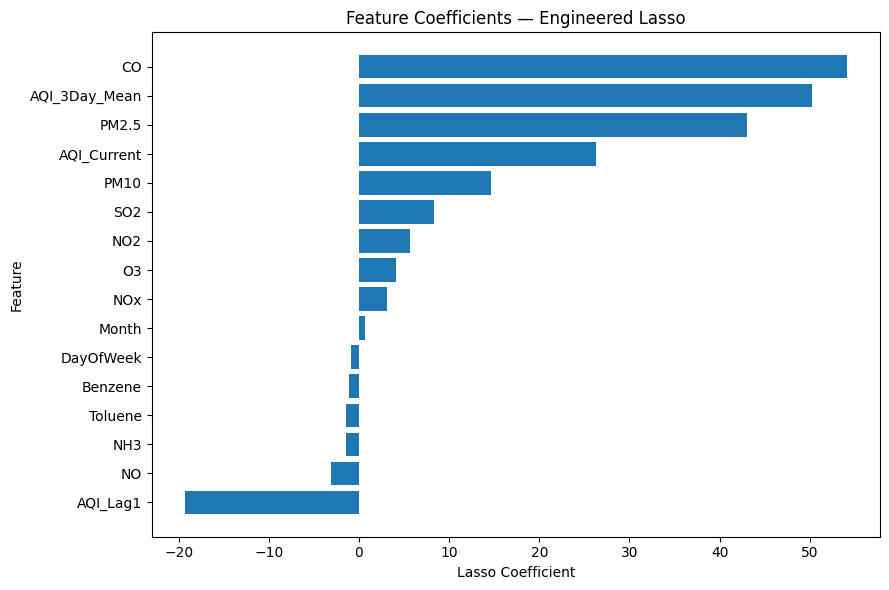

Coefficient graph saved successfully.


In [484]:
# ============================================================
# W4 CELL 38 — LASSO COEFFICIENT PLOT
# ============================================================

plot_df = coefficient_df.sort_values(
    "Coefficient"
)

plt.figure(figsize=(9, 6))

plt.barh(
    plot_df["Feature"],
    plot_df["Coefficient"]
)

plt.xlabel("Lasso Coefficient")
plt.ylabel("Feature")

plt.title(
    "Feature Coefficients — Engineered Lasso"
)

plt.tight_layout()

plt.savefig(
    "../graphs/w4_lasso_feature_coefficients.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Coefficient graph saved successfully.")

In [485]:
# ============================================================
# W4 CELL 39 — SAVE LASSO COEFFICIENTS
# ============================================================

coefficient_df.to_csv(
    "../graphs/w4_lasso_coefficients.csv",
    index=False
)

print("=" * 70)
print("LASSO COEFFICIENT ANALYSIS SAVED")
print("=" * 70)

print("Saved successfully:")
print("../graphs/w4_lasso_coefficients.csv")

LASSO COEFFICIENT ANALYSIS SAVED
Saved successfully:
../graphs/w4_lasso_coefficients.csv


In [486]:
# ============================================================
# W4 CELL 40 — FINAL REGRESSION SUMMARY
# ============================================================

final_regression_summary = pd.DataFrame({
    "Model": [
        "OLS",
        "Ridge",
        "Lasso",
        "Engineered Ridge",
        "Engineered Lasso"
    ],
    "Features": [
        11,
        11,
        11,
        16,
        16
    ],
    "MAE": [
        ols_mae_w4,
        ridge_mae,
        lasso_mae,
        ridge_fe_mae,
        lasso_fe_mae
    ],
    "RMSE": [
        ols_rmse_w4,
        ridge_rmse,
        lasso_rmse,
        ridge_fe_rmse,
        lasso_fe_rmse
    ],
    "R2": [
        ols_r2_w4,
        ridge_r2,
        lasso_r2,
        ridge_fe_r2,
        lasso_fe_r2
    ]
})

print("=" * 70)
print("AEROPURE — W4 FINAL REGRESSION SUMMARY")
print("=" * 70)

display(final_regression_summary)

final_regression_summary.to_csv(
    "../graphs/w4_final_regression_summary.csv",
    index=False
)

print("Final regression summary saved successfully.")

AEROPURE — W4 FINAL REGRESSION SUMMARY


,Model,Features,MAE,RMSE,R2
0,OLS,11,25.694745,42.475218,0.833065
1,Ridge,11,25.695081,42.474451,0.833072
2,Lasso,11,25.688423,42.459937,0.833186
3,Engineered Ridge,16,22.134959,40.727729,0.845156
4,Engineered Lasso,16,22.128465,40.715327,0.845250


Final regression summary saved successfully.


In [487]:
# ============================================================
# W5 CELL 41 — LEAKAGE-FREE TIME-BASED CROSS-VALIDATION
# ============================================================

from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

print("=" * 70)
print("W5 LEAKAGE-FREE CROSS-VALIDATION SETUP")
print("=" * 70)


# ------------------------------------------------------------
# IMPORTANT:
# Use RAW feature-engineered training data.
# Do NOT use X_train_fe_scaled here.
# ------------------------------------------------------------

X_cv_raw = train_fe[features_fe].copy()
y_cv_raw = train_fe["Tomorrow_AQI"].copy()


# ------------------------------------------------------------
# Create chronological folds based on UNIQUE DATES
# ------------------------------------------------------------

unique_cv_dates = np.array(
    sorted(train_fe["Date"].unique())
)

date_splitter = TimeSeriesSplit(
    n_splits=5
)


# ------------------------------------------------------------
# Store row indices for each fold
# ------------------------------------------------------------

cv_splits = []

for fold, (train_date_idx, val_date_idx) in enumerate(
    date_splitter.split(unique_cv_dates),
    start=1
):

    train_dates = unique_cv_dates[train_date_idx]
    val_dates = unique_cv_dates[val_date_idx]

    train_idx = np.where(
        train_fe["Date"].isin(train_dates)
    )[0]

    val_idx = np.where(
        train_fe["Date"].isin(val_dates)
    )[0]

    cv_splits.append(
        (train_idx, val_idx)
    )

    print(
        f"Fold {fold}: "
        f"Train rows = {len(train_idx)}, "
        f"Validation rows = {len(val_idx)}"
    )

    print(
        f"         Train dates = "
        f"{train_dates[0]} → {train_dates[-1]}"
    )

    print(
        f"         Validation dates = "
        f"{val_dates[0]} → {val_dates[-1]}"
    )


# ------------------------------------------------------------
# Leakage-free preprocessing function
# ------------------------------------------------------------

def prepare_cv_fold(train_idx, val_idx):

    fold_train = train_fe.iloc[
        train_idx
    ].copy()

    fold_val = train_fe.iloc[
        val_idx
    ].copy()


    # --------------------------------------------------------
    # IMPUTATION
    # Fit medians ONLY on this fold's training data
    # --------------------------------------------------------

    for col in features_fe:

        city_medians = (
            fold_train
            .groupby("City")[col]
            .median()
        )

        overall_median = (
            fold_train[col]
            .median()
        )

        # Training data
        fold_train[col] = (
            fold_train[col]
            .fillna(
                fold_train["City"]
                .map(city_medians)
            )
            .fillna(overall_median)
        )

        # Validation data
        fold_val[col] = (
            fold_val[col]
            .fillna(
                fold_val["City"]
                .map(city_medians)
            )
            .fillna(overall_median)
        )


    # --------------------------------------------------------
    # SCALING
    # Fit scaler ONLY on this fold's training data
    # --------------------------------------------------------

    fold_scaler = StandardScaler()

    X_train_fold = (
        fold_scaler.fit_transform(
            fold_train[features_fe]
        )
    )

    X_val_fold = (
        fold_scaler.transform(
            fold_val[features_fe]
        )
    )


    # --------------------------------------------------------
    # TARGET
    # --------------------------------------------------------

    y_train_fold = (
        fold_train["Tomorrow_AQI"]
        .copy()
    )

    y_val_fold = (
        fold_val["Tomorrow_AQI"]
        .copy()
    )


    return (
        X_train_fold,
        X_val_fold,
        y_train_fold,
        y_val_fold
    )


print("\nLeakage-free preprocessing function created.")
print("Imputation and scaling will be fitted separately")
print("inside every CV fold.")

W5 LEAKAGE-FREE CROSS-VALIDATION SETUP
Fold 1: Train rows = 1221, Validation rows = 1628
         Train dates = 2015-01-02 00:00:00 → 2015-09-28 00:00:00
         Validation dates = 2015-09-29 00:00:00 → 2016-06-21 00:00:00
Fold 2: Train rows = 2849, Validation rows = 1994
         Train dates = 2015-01-02 00:00:00 → 2016-06-21 00:00:00
         Validation dates = 2016-06-22 00:00:00 → 2017-03-15 00:00:00
Fold 3: Train rows = 4843, Validation rows = 2265
         Train dates = 2015-01-02 00:00:00 → 2017-03-15 00:00:00
         Validation dates = 2017-03-16 00:00:00 → 2017-12-07 00:00:00
Fold 4: Train rows = 7108, Validation rows = 3981
         Train dates = 2015-01-02 00:00:00 → 2017-12-07 00:00:00
         Validation dates = 2017-12-08 00:00:00 → 2018-08-31 00:00:00
Fold 5: Train rows = 11089, Validation rows = 4547
         Train dates = 2015-01-02 00:00:00 → 2018-08-31 00:00:00
         Validation dates = 2018-09-01 00:00:00 → 2019-05-25 00:00:00

Leakage-free preprocessing functio

In [488]:
# ============================================================
# W5 CELL 42 — RIDGE REGRESSION CROSS-VALIDATION
# ============================================================

from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
import numpy as np
import pandas as pd

print("=" * 70)
print("RIDGE REGRESSION — LEAKAGE-FREE TIME-BASED CV")
print("=" * 70)

# ------------------------------------------------------------
# Alpha values to test
# ------------------------------------------------------------

ridge_alphas = [
    0.001,
    0.01,
    0.1,
    1,
    10,
    100
]

ridge_cv_results = []

# ------------------------------------------------------------
# Evaluate every alpha using the same chronological folds
# ------------------------------------------------------------

for alpha in ridge_alphas:

    fold_mae = []

    for fold, (train_idx, val_idx) in enumerate(
        cv_splits,
        start=1
    ):

        # Fold-specific preprocessing
        (
            X_train_fold,
            X_val_fold,
            y_train_fold,
            y_val_fold
        ) = prepare_cv_fold(
            train_idx,
            val_idx
        )

        # ----------------------------------------------------
        # Train Ridge
        # ----------------------------------------------------

        model = Ridge(
            alpha=alpha
        )

        model.fit(
            X_train_fold,
            y_train_fold
        )

        # ----------------------------------------------------
        # Validation prediction
        # ----------------------------------------------------

        y_pred = model.predict(
            X_val_fold
        )

        mae = mean_absolute_error(
            y_val_fold,
            y_pred
        )

        fold_mae.append(mae)

    # --------------------------------------------------------
    # Mean and standard error
    # --------------------------------------------------------

    mean_mae = np.mean(fold_mae)

    se_mae = (
        np.std(
            fold_mae,
            ddof=1
        )
        / np.sqrt(len(fold_mae))
    )

    ridge_cv_results.append({
        "Alpha": alpha,
        "Mean_CV_MAE": mean_mae,
        "SE": se_mae
    })

# ------------------------------------------------------------
# Results table
# ------------------------------------------------------------

ridge_cv_results = pd.DataFrame(
    ridge_cv_results
)

ridge_cv_results = ridge_cv_results.sort_values(
    "Mean_CV_MAE"
).reset_index(drop=True)

print("\nRidge CV Results:")
print(
    ridge_cv_results.to_string(
        index=False
    )
)

# ------------------------------------------------------------
# Best alpha
# ------------------------------------------------------------

best_ridge_mae = ridge_cv_results[
    "Mean_CV_MAE"
].min()

best_ridge_alpha = ridge_cv_results.loc[
    ridge_cv_results["Mean_CV_MAE"].idxmin(),
    "Alpha"
]

best_ridge_se = ridge_cv_results.loc[
    ridge_cv_results["Mean_CV_MAE"].idxmin(),
    "SE"
]

print("\n" + "-" * 70)

print(
    f"Best Ridge alpha: {best_ridge_alpha}"
)

print(
    f"Best Mean CV MAE: {best_ridge_mae:.4f}"
)

print(
    f"Standard Error: {best_ridge_se:.4f}"
)

print("-" * 70)

RIDGE REGRESSION — LEAKAGE-FREE TIME-BASED CV

Ridge CV Results:
  Alpha  Mean_CV_MAE       SE
  0.001    37.263625 1.833542
  0.010    37.263628 1.833527
  0.100    37.263657 1.833378
  1.000    37.264008 1.831928
 10.000    37.272749 1.820890
100.000    37.525293 1.829346

----------------------------------------------------------------------
Best Ridge alpha: 0.001
Best Mean CV MAE: 37.2636
Standard Error: 1.8335
----------------------------------------------------------------------


In [489]:
# ============================================================
# W5 CELL 43 — BEST RIDGE ALPHA
# ============================================================

best_ridge_idx = (
    ridge_cv_results["Mean_CV_MAE"]
    .idxmin()
)

best_ridge_alpha = (
    ridge_cv_results
    .loc[best_ridge_idx, "Alpha"]
)

best_ridge_mae = (
    ridge_cv_results
    .loc[best_ridge_idx, "Mean_CV_MAE"]
)

best_ridge_se = (
    ridge_cv_results
    .loc[best_ridge_idx, "SE"]
)

print("=" * 70)
print("BEST RIDGE MODEL")
print("=" * 70)

print(
    "Best alpha:",
    best_ridge_alpha
)

print(
    f"Best CV MAE: {best_ridge_mae:.4f}"
)

print(
    f"Standard error: {best_ridge_se:.4f}"
)

BEST RIDGE MODEL
Best alpha: 0.001
Best CV MAE: 37.2636
Standard error: 1.8335


In [490]:
# ============================================================
# W5 CELL 44 — RIDGE ONE-STANDARD-ERROR RULE
# ============================================================

ridge_threshold = (
    best_ridge_mae +
    best_ridge_se
)

ridge_candidates_1se = (
    ridge_cv_results[
        ridge_cv_results["Mean_CV_MAE"]
        <= ridge_threshold
    ]
)

ridge_alpha_1se = (
    ridge_candidates_1se["Alpha"]
    .max()
)

print("=" * 70)
print("RIDGE ONE-STANDARD-ERROR RULE")
print("=" * 70)

print(
    f"Best CV MAE: {best_ridge_mae:.4f}"
)

print(
    f"Best CV SE : {best_ridge_se:.4f}"
)

print(
    f"1-SE threshold: {ridge_threshold:.4f}"
)

print(
    "Selected alpha using 1-SE rule:",
    ridge_alpha_1se
)

print("\nCandidate models within 1-SE:")

print(
    ridge_candidates_1se[
        ["Alpha", "Mean_CV_MAE", "SE"]
    ].to_string(index=False)
)

RIDGE ONE-STANDARD-ERROR RULE
Best CV MAE: 37.2636
Best CV SE : 1.8335
1-SE threshold: 39.0972
Selected alpha using 1-SE rule: 100.0

Candidate models within 1-SE:
  Alpha  Mean_CV_MAE       SE
  0.001    37.263625 1.833542
  0.010    37.263628 1.833527
  0.100    37.263657 1.833378
  1.000    37.264008 1.831928
 10.000    37.272749 1.820890
100.000    37.525293 1.829346


In [491]:
# ============================================================
# W5 CELL 45 — LASSO REGRESSION CROSS-VALIDATION
# ============================================================

from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error
import numpy as np
import pandas as pd

print("=" * 70)
print("LASSO REGRESSION — LEAKAGE-FREE TIME-BASED CV")
print("=" * 70)


# ------------------------------------------------------------
# Alpha values to test
# ------------------------------------------------------------

lasso_alphas = [
    0.0001,
    0.001,
    0.01,
    0.1,
    1.0,
    10.0
]

lasso_cv_results = []


# ------------------------------------------------------------
# Evaluate every alpha using the corrected folds
# ------------------------------------------------------------

for alpha in lasso_alphas:

    fold_mae = []

    for fold, (train_idx, val_idx) in enumerate(
        cv_splits,
        start=1
    ):

        # Fold-specific preprocessing
        (
            X_train_fold,
            X_val_fold,
            y_train_fold,
            y_val_fold
        ) = prepare_cv_fold(
            train_idx,
            val_idx
        )


        # ----------------------------------------------------
        # Train Lasso
        # ----------------------------------------------------

        model = Lasso(
            alpha=alpha,
            max_iter=20000
        )

        model.fit(
            X_train_fold,
            y_train_fold
        )


        # ----------------------------------------------------
        # Validation prediction
        # ----------------------------------------------------

        y_pred = model.predict(
            X_val_fold
        )

        mae = mean_absolute_error(
            y_val_fold,
            y_pred
        )

        fold_mae.append(mae)


    # --------------------------------------------------------
    # Mean, standard deviation and standard error
    # --------------------------------------------------------

    mean_mae = np.mean(fold_mae)

    std_mae = np.std(
        fold_mae,
        ddof=1
    )

    se_mae = (
        std_mae /
        np.sqrt(len(fold_mae))
    )


    lasso_cv_results.append({
        "Alpha": alpha,
        "Mean_CV_MAE": mean_mae,
        "Std": std_mae,
        "SE": se_mae
    })


# ------------------------------------------------------------
# Results table
# ------------------------------------------------------------

lasso_cv_results = pd.DataFrame(
    lasso_cv_results
)

lasso_cv_results = lasso_cv_results.sort_values(
    "Mean_CV_MAE"
).reset_index(drop=True)


print("\nLasso CV Results:")

print(
    lasso_cv_results.to_string(
        index=False
    )
)


# ------------------------------------------------------------
# Best Lasso alpha
# ------------------------------------------------------------

best_lasso_idx = (
    lasso_cv_results["Mean_CV_MAE"]
    .idxmin()
)

best_lasso_alpha = (
    lasso_cv_results
    .loc[best_lasso_idx, "Alpha"]
)

best_lasso_mae = (
    lasso_cv_results
    .loc[best_lasso_idx, "Mean_CV_MAE"]
)

best_lasso_se = (
    lasso_cv_results
    .loc[best_lasso_idx, "SE"]
)


print("\n" + "-" * 70)

print(
    f"Best Lasso alpha: {best_lasso_alpha}"
)

print(
    f"Best Mean CV MAE: {best_lasso_mae:.4f}"
)

print(
    f"Standard Error: {best_lasso_se:.4f}"
)

print("-" * 70)

LASSO REGRESSION — LEAKAGE-FREE TIME-BASED CV

Lasso CV Results:
  Alpha  Mean_CV_MAE      Std       SE
 0.1000    37.244435 3.997823 1.787881
 1.0000    37.245444 3.636284 1.626196
 0.0100    37.261649 4.090045 1.829124
 0.0010    37.263508 4.099045 1.833149
 0.0001    37.263613 4.099841 1.833504
10.0000    40.255851 2.610400 1.167406

----------------------------------------------------------------------
Best Lasso alpha: 0.1
Best Mean CV MAE: 37.2444
Standard Error: 1.7879
----------------------------------------------------------------------


In [492]:
# ============================================================
# W5 CELL 46 — LASSO ONE-STANDARD-ERROR RULE
# ============================================================

best_lasso_idx = (
    lasso_cv_results["Mean_CV_MAE"]
    .idxmin()
)

best_lasso_alpha = (
    lasso_cv_results
    .loc[best_lasso_idx, "Alpha"]
)

best_lasso_mae = (
    lasso_cv_results
    .loc[best_lasso_idx, "Mean_CV_MAE"]
)

best_lasso_se = (
    lasso_cv_results
    .loc[best_lasso_idx, "SE"]
)

lasso_threshold = (
    best_lasso_mae +
    best_lasso_se
)

lasso_candidates_1se = (
    lasso_cv_results[
        lasso_cv_results["Mean_CV_MAE"]
        <= lasso_threshold
    ]
)

# Select the largest alpha within 1-SE
lasso_alpha_1se = (
    lasso_candidates_1se["Alpha"]
    .max()
)

print("=" * 70)
print("LASSO ONE-STANDARD-ERROR RULE")
print("=" * 70)

print(
    f"Best alpha: {best_lasso_alpha}"
)

print(
    f"Best CV MAE: {best_lasso_mae:.4f}"
)

print(
    f"Standard error: {best_lasso_se:.4f}"
)

print(
    f"1-SE threshold: {lasso_threshold:.4f}"
)

print(
    "Selected alpha using 1-SE rule:",
    lasso_alpha_1se
)

print("\nCandidate models within 1-SE:")

print(
    lasso_candidates_1se[
        ["Alpha", "Mean_CV_MAE", "Std", "SE"]
    ].to_string(index=False)
)

LASSO ONE-STANDARD-ERROR RULE
Best alpha: 0.1
Best CV MAE: 37.2444
Standard error: 1.7879
1-SE threshold: 39.0323
Selected alpha using 1-SE rule: 1.0

Candidate models within 1-SE:
 Alpha  Mean_CV_MAE      Std       SE
0.1000    37.244435 3.997823 1.787881
1.0000    37.245444 3.636284 1.626196
0.0100    37.261649 4.090045 1.829124
0.0010    37.263508 4.099045 1.833149
0.0001    37.263613 4.099841 1.833504


In [493]:
# ============================================================
# W5 CELL 47 — FINAL TUNED RIDGE
# ============================================================

final_ridge = Ridge(
    alpha=ridge_alpha_1se
)

# Train on the complete training set
final_ridge.fit(
    X_train_fe_scaled,
    y_train_fe
)

# Predict on untouched test set
y_pred_final_ridge = final_ridge.predict(
    X_test_fe_scaled
)

# Evaluate
ridge_final_mae = mean_absolute_error(
    y_test_fe,
    y_pred_final_ridge
)

ridge_final_rmse = np.sqrt(
    mean_squared_error(
        y_test_fe,
        y_pred_final_ridge
    )
)

ridge_final_r2 = r2_score(
    y_test_fe,
    y_pred_final_ridge
)

print("=" * 70)
print("FINAL TUNED RIDGE — TEST PERFORMANCE")
print("=" * 70)

print(
    f"Selected alpha: {ridge_alpha_1se}"
)

print(
    f"MAE  : {ridge_final_mae:.4f}"
)

print(
    f"RMSE : {ridge_final_rmse:.4f}"
)

print(
    f"R²   : {ridge_final_r2:.4f}"
)

FINAL TUNED RIDGE — TEST PERFORMANCE
Selected alpha: 100.0
MAE  : 22.1342
RMSE : 40.7133
R²   : 0.8453


In [494]:
# ============================================================
# W5 CELL 48 — FINAL TUNED LASSO
# ============================================================

final_lasso = Lasso(
    alpha=lasso_alpha_1se,
    max_iter=20000
)

# Train on the complete training set
final_lasso.fit(
    X_train_fe_scaled,
    y_train_fe
)

# Predict on untouched test set
y_pred_final_lasso = final_lasso.predict(
    X_test_fe_scaled
)

# Evaluate
lasso_final_mae = mean_absolute_error(
    y_test_fe,
    y_pred_final_lasso
)

lasso_final_rmse = np.sqrt(
    mean_squared_error(
        y_test_fe,
        y_pred_final_lasso
    )
)

lasso_final_r2 = r2_score(
    y_test_fe,
    y_pred_final_lasso
)

print("=" * 70)
print("FINAL TUNED LASSO — TEST PERFORMANCE")
print("=" * 70)

print(
    f"Selected alpha: {lasso_alpha_1se}"
)

print(
    f"MAE  : {lasso_final_mae:.4f}"
)

print(
    f"RMSE : {lasso_final_rmse:.4f}"
)

print(
    f"R²   : {lasso_final_r2:.4f}"
)

FINAL TUNED LASSO — TEST PERFORMANCE
Selected alpha: 1.0
MAE  : 21.9038
RMSE : 40.3824
R²   : 0.8478


In [495]:
# ============================================================
# W5 CELL 49 — FINAL TUNED MODEL COMPARISON
# ============================================================

w5_regression_results = pd.DataFrame({
    "Model": [
        "Ridge — 1-SE",
        "Lasso — 1-SE"
    ],
    "Alpha": [
        ridge_alpha_1se,
        lasso_alpha_1se
    ],
    "MAE": [
        final_ridge_mae,
        final_lasso_mae
    ],
    "RMSE": [
        final_ridge_rmse,
        final_lasso_rmse
    ],
    "R2": [
        final_ridge_r2,
        final_lasso_r2
    ]
})

print("=" * 70)
print("W5 FINAL TUNED REGRESSION RESULTS")
print("=" * 70)

display(w5_regression_results)

W5 FINAL TUNED REGRESSION RESULTS


,Model,Alpha,MAE,RMSE,R2
0,Ridge — 1-SE,100.0,22.134196,40.713274,0.845266
1,Lasso — 1-SE,1.0,21.903789,40.382361,0.847771


In [496]:
# ============================================================
# W5 CELL 50 — SAVE TUNED RESULTS
# ============================================================

w5_regression_results.to_csv(
    "../graphs/w5_tuned_regression_results.csv",
    index=False
)

ridge_cv_results.to_csv(
    "../graphs/w5_ridge_cv_results.csv",
    index=False
)

lasso_cv_results.to_csv(
    "../graphs/w5_lasso_cv_results.csv",
    index=False
)

print("W5 regression results saved successfully.")

W5 regression results saved successfully.


In [497]:
# ============================================================
# W5 CELL 50A — HAZARDOUS TARGET FOR FEATURE-ENGINEERED DATA
# ============================================================

HAZARDOUS_THRESHOLD = 301

train_fe_imp["Hazardous_Tomorrow"] = (
    train_fe_imp["Tomorrow_AQI"] >= HAZARDOUS_THRESHOLD
).astype(int)

test_fe_imp["Hazardous_Tomorrow"] = (
    test_fe_imp["Tomorrow_AQI"] >= HAZARDOUS_THRESHOLD
).astype(int)

print("=" * 70)
print("W5 HAZARDOUS TARGET CHECK")
print("=" * 70)

print("Threshold:", HAZARDOUS_THRESHOLD)

print("\nTRAIN:")
print(
    train_fe_imp["Hazardous_Tomorrow"]
    .value_counts()
    .sort_index()
)

print("\nTEST:")
print(
    test_fe_imp["Hazardous_Tomorrow"]
    .value_counts()
    .sort_index()
)

W5 HAZARDOUS TARGET CHECK
Threshold: 301

TRAIN:
Hazardous_Tomorrow
0    12642
1     2994
Name: count, dtype: int64

TEST:
Hazardous_Tomorrow
0    8082
1     599
Name: count, dtype: int64


In [498]:
# ============================================================
# W5 CELL 51 — LOGISTIC REGRESSION CROSS-VALIDATION
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, recall_score
import numpy as np
import pandas as pd

print("=" * 70)
print("LOGISTIC REGRESSION — LEAKAGE-FREE TIME-BASED CV")
print("=" * 70)


# ------------------------------------------------------------
# C values to test
# ------------------------------------------------------------

logistic_C_values = [
    0.001,
    0.01,
    0.1,
    1.0,
    10.0,
    100.0
]

logistic_cv_results = []


# ------------------------------------------------------------
# Evaluate every C using corrected chronological folds
# ------------------------------------------------------------

for C in logistic_C_values:

    fold_f1 = []
    fold_recall = []

    for fold, (train_idx, val_idx) in enumerate(
        cv_splits,
        start=1
    ):

        # ----------------------------------------------------
        # Fold-specific preprocessing
        # ----------------------------------------------------

        (
            X_train_fold,
            X_val_fold,
            y_train_aqi,
            y_val_aqi
        ) = prepare_cv_fold(
            train_idx,
            val_idx
        )


        # ----------------------------------------------------
        # Classification target
        #
        # IMPORTANT:
        # Derive the hazardous label from Tomorrow_AQI
        # inside each fold.
        # ----------------------------------------------------

        y_train_fold = (
            y_train_aqi >= HAZARDOUS_THRESHOLD
        ).astype(int)

        y_val_fold = (
            y_val_aqi >= HAZARDOUS_THRESHOLD
        ).astype(int)


        # ----------------------------------------------------
        # Logistic Regression
        # ----------------------------------------------------

        model = LogisticRegression(
            C=C,
            class_weight="balanced",
            max_iter=2000,
            random_state=42
        )

        model.fit(
            X_train_fold,
            y_train_fold
        )


        # ----------------------------------------------------
        # Validation prediction
        # ----------------------------------------------------

        y_pred = model.predict(
            X_val_fold
        )


        # ----------------------------------------------------
        # Evaluation
        # ----------------------------------------------------

        fold_f1.append(
            f1_score(
                y_val_fold,
                y_pred,
                zero_division=0
            )
        )

        fold_recall.append(
            recall_score(
                y_val_fold,
                y_pred,
                zero_division=0
            )
        )


    # --------------------------------------------------------
    # Mean, standard deviation and standard error
    # --------------------------------------------------------

    mean_f1 = np.mean(fold_f1)

    std_f1 = np.std(
        fold_f1,
        ddof=1
    )

    se_f1 = (
        std_f1 /
        np.sqrt(len(fold_f1))
    )

    mean_recall = np.mean(
        fold_recall
    )


    logistic_cv_results.append({
        "C": C,
        "Mean_F1": mean_f1,
        "Std_F1": std_f1,
        "SE_F1": se_f1,
        "Mean_Recall": mean_recall
    })


# ------------------------------------------------------------
# Results table
# ------------------------------------------------------------

logistic_cv_results = pd.DataFrame(
    logistic_cv_results
)

logistic_cv_results = logistic_cv_results.sort_values(
    "Mean_F1",
    ascending=False
).reset_index(drop=True)


print("\nLogistic Regression CV Results:")

print(
    logistic_cv_results.to_string(
        index=False
    )
)


# ------------------------------------------------------------
# Best C
# ------------------------------------------------------------

best_logistic_idx = (
    logistic_cv_results["Mean_F1"]
    .idxmax()
)

best_logistic_C = (
    logistic_cv_results
    .loc[best_logistic_idx, "C"]
)

best_logistic_f1 = (
    logistic_cv_results
    .loc[best_logistic_idx, "Mean_F1"]
)

best_logistic_se = (
    logistic_cv_results
    .loc[best_logistic_idx, "SE_F1"]
)

best_logistic_recall = (
    logistic_cv_results
    .loc[best_logistic_idx, "Mean_Recall"]
)


print("\n" + "-" * 70)

print(
    f"Best Logistic C: {best_logistic_C}"
)

print(
    f"Best Mean CV F1: {best_logistic_f1:.4f}"
)

print(
    f"Standard Error: {best_logistic_se:.4f}"
)

print(
    f"Mean CV Recall: {best_logistic_recall:.4f}"
)

print("-" * 70)

LOGISTIC REGRESSION — LEAKAGE-FREE TIME-BASED CV

Logistic Regression CV Results:
      C  Mean_F1   Std_F1    SE_F1  Mean_Recall
  0.100 0.845973 0.028352 0.012679     0.929159
 10.000 0.845947 0.028591 0.012786     0.928584
100.000 0.845721 0.028544 0.012765     0.928155
  1.000 0.845617 0.028618 0.012799     0.927727
  0.010 0.839089 0.027795 0.012430     0.935041
  0.001 0.822169 0.029388 0.013143     0.924079

----------------------------------------------------------------------
Best Logistic C: 0.1
Best Mean CV F1: 0.8460
Standard Error: 0.0127
Mean CV Recall: 0.9292
----------------------------------------------------------------------


In [499]:
# ============================================================
# W5 CELL 52 — LOGISTIC REGRESSION 1-SE RULE
# ============================================================

# ------------------------------------------------------------
# Find the model with highest mean F1
# ------------------------------------------------------------

best_logistic_idx = (
    logistic_cv_results["Mean_F1"]
    .idxmax()
)

best_logistic_C = (
    logistic_cv_results
    .loc[best_logistic_idx, "C"]
)

best_logistic_f1 = (
    logistic_cv_results
    .loc[best_logistic_idx, "Mean_F1"]
)

best_logistic_se = (
    logistic_cv_results
    .loc[best_logistic_idx, "SE_F1"]
)


# ------------------------------------------------------------
# 1-SE threshold
#
# For F1, higher is better.
# Models within one SE of the best:
# F1 >= best F1 - SE
# ------------------------------------------------------------

logistic_threshold = (
    best_logistic_f1 -
    best_logistic_se
)


logistic_candidates_1se = (
    logistic_cv_results[
        logistic_cv_results["Mean_F1"]
        >= logistic_threshold
    ]
)


# ------------------------------------------------------------
# Select strongest regularization
#
# Smaller C = stronger regularization
# ------------------------------------------------------------

logistic_C_1se = (
    logistic_candidates_1se["C"]
    .min()
)


print("=" * 70)
print("LOGISTIC REGRESSION — ONE STANDARD ERROR RULE")
print("=" * 70)

print(
    f"Best C: {best_logistic_C}"
)

print(
    f"Best CV F1: {best_logistic_f1:.4f}"
)

print(
    f"SE: {best_logistic_se:.4f}"
)

print(
    f"1-SE threshold: {logistic_threshold:.4f}"
)

print(
    "Selected C using 1-SE rule:",
    logistic_C_1se
)

print("\nModels within 1-SE:")

print(
    logistic_candidates_1se[
        [
            "C",
            "Mean_F1",
            "Std_F1",
            "SE_F1",
            "Mean_Recall"
        ]
    ].to_string(index=False)
)

LOGISTIC REGRESSION — ONE STANDARD ERROR RULE
Best C: 0.1
Best CV F1: 0.8460
SE: 0.0127
1-SE threshold: 0.8333
Selected C using 1-SE rule: 0.01

Models within 1-SE:
     C  Mean_F1   Std_F1    SE_F1  Mean_Recall
  0.10 0.845973 0.028352 0.012679     0.929159
 10.00 0.845947 0.028591 0.012786     0.928584
100.00 0.845721 0.028544 0.012765     0.928155
  1.00 0.845617 0.028618 0.012799     0.927727
  0.01 0.839089 0.027795 0.012430     0.935041


In [500]:
# ============================================================
# W5 CELL 53 — FINAL TUNED LOGISTIC REGRESSION
# ============================================================

final_logistic = LogisticRegression(
    C=logistic_C_1se,
    class_weight="balanced",
    max_iter=2000,
    random_state=42
)

# ------------------------------------------------------------
# Classification targets
# ------------------------------------------------------------

y_train_cls = (
    y_train_fe >= HAZARDOUS_THRESHOLD
).astype(int)

y_test_cls = (
    y_test_fe >= HAZARDOUS_THRESHOLD
).astype(int)


# ------------------------------------------------------------
# Train on the complete training set
# ------------------------------------------------------------

final_logistic.fit(
    X_train_fe_scaled,
    y_train_cls
)


# ------------------------------------------------------------
# Final test predictions
# ------------------------------------------------------------

y_pred_final_cls = final_logistic.predict(
    X_test_fe_scaled
)

y_prob_final_cls = (
    final_logistic
    .predict_proba(X_test_fe_scaled)[:, 1]
)


print("=" * 70)
print("FINAL TUNED LOGISTIC REGRESSION")
print("=" * 70)

print(
    f"Selected C: {logistic_C_1se}"
)

print(
    f"Test predictions: {len(y_pred_final_cls)}"
)

print(
    f"Actual test samples: {len(y_test_cls)}"
)

FINAL TUNED LOGISTIC REGRESSION
Selected C: 0.01
Test predictions: 8681
Actual test samples: 8681


In [501]:
# ============================================================
# W5 CELL 54 — FINAL LOGISTIC CLASSIFICATION EVALUATION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

print("=" * 70)
print("FINAL LOGISTIC REGRESSION — TEST PERFORMANCE")
print("=" * 70)


# ------------------------------------------------------------
# Evaluation metrics
# ------------------------------------------------------------

final_accuracy = accuracy_score(
    y_test_cls,
    y_pred_final_cls
)

final_precision = precision_score(
    y_test_cls,
    y_pred_final_cls,
    zero_division=0
)

final_recall = recall_score(
    y_test_cls,
    y_pred_final_cls,
    zero_division=0
)

final_f1 = f1_score(
    y_test_cls,
    y_pred_final_cls,
    zero_division=0
)

final_roc_auc = roc_auc_score(
    y_test_cls,
    y_prob_final_cls
)


# ------------------------------------------------------------
# Confusion matrix
# ------------------------------------------------------------

cm = confusion_matrix(
    y_test_cls,
    y_pred_final_cls
)


# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print(f"Selected C : {logistic_C_1se}")

print(f"Accuracy   : {final_accuracy:.4f}")
print(f"Precision  : {final_precision:.4f}")
print(f"Recall     : {final_recall:.4f}")
print(f"F1 Score   : {final_f1:.4f}")
print(f"ROC-AUC    : {final_roc_auc:.4f}")

print("\nConfusion Matrix:")
print(cm)

FINAL LOGISTIC REGRESSION — TEST PERFORMANCE
Selected C : 0.01
Accuracy   : 0.9664
Precision  : 0.6897
Recall     : 0.9316
F1 Score   : 0.7926
ROC-AUC    : 0.9896

Confusion Matrix:
[[7831  251]
 [  41  558]]


In [502]:
# ============================================================
# W5 CELL 55 — W4 VS W5 CLASSIFICATION COMPARISON
# ============================================================

classification_comparison = pd.DataFrame({
    "Model": [
        "W4 Logistic Regression",
        "W5 Tuned Logistic — 1-SE"
    ],
    "C": [
        1.0,
        logistic_C_1se
    ],
    "Accuracy": [
        accuracy,
        final_accuracy
    ],
    "Precision": [
        precision,
        final_precision
    ],
    "Recall": [
        recall,
        final_recall
    ],
    "F1": [
        f1,
        final_f1
    ],
    "ROC-AUC": [
        roc_auc,
        final_roc_auc
    ]
})

print("=" * 70)
print("W4 VS W5 CLASSIFICATION COMPARISON")
print("=" * 70)

display(classification_comparison)

W4 VS W5 CLASSIFICATION COMPARISON


,Model,C,Accuracy,Precision,Recall,F1,ROC-AUC
0,W4 Logistic Regression,1.00,0.969090,0.70632,0.940594,0.806794,0.991235
1,W5 Tuned Logistic — 1-SE,0.01,0.966363,0.68974,0.931553,0.792614,0.989630


In [503]:
# ============================================================
# W5 CELL 56 — SAVE CLASSIFICATION COMPARISON
# ============================================================

classification_comparison.to_csv(
    "../graphs/w5_classification_comparison.csv",
    index=False
)

logistic_cv_results.to_csv(
    "../graphs/w5_logistic_cv_results.csv",
    index=False
)

print("W5 classification results saved successfully.")

W5 classification results saved successfully.


W5 FINAL TUNED CONFUSION MATRIX
[[7831  251]
 [  41  558]]


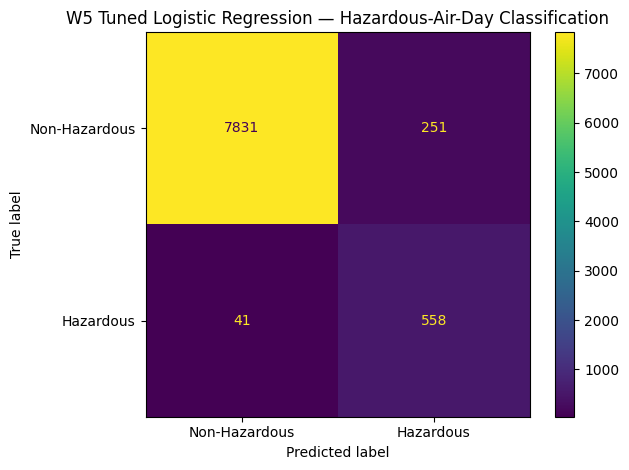

W5 confusion matrix saved successfully.


In [504]:
# ============================================================
# W5 CELL 57 — FINAL TUNED CONFUSION MATRIX
# ============================================================

final_cm = confusion_matrix(
    test_fe_imp["Hazardous_Tomorrow"],
    y_pred_final_cls
)

print("=" * 70)
print("W5 FINAL TUNED CONFUSION MATRIX")
print("=" * 70)

print(final_cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=final_cm,
    display_labels=[
        "Non-Hazardous",
        "Hazardous"
    ]
)

disp.plot()

plt.title(
    "W5 Tuned Logistic Regression — Hazardous-Air-Day Classification"
)

plt.tight_layout()

plt.savefig(
    "../graphs/w5_final_logistic_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("W5 confusion matrix saved successfully.")

In [505]:
# ============================================================
# W5 CELL 58 — FINAL TUNED REGRESSION COMPARISON
# ============================================================

final_tuned_regression = pd.DataFrame({
    "Model": [
        "W4 Engineered Lasso",
        "W5 Tuned Ridge — 1-SE",
        "W5 Tuned Lasso — 1-SE"
    ],
    "Alpha": [
        0.01,
        ridge_alpha_1se,
        lasso_alpha_1se
    ],
    "MAE": [
        lasso_fe_mae,
        final_ridge_mae,
        final_lasso_mae
    ],
    "RMSE": [
        lasso_fe_rmse,
        final_ridge_rmse,
        final_lasso_rmse
    ],
    "R2": [
        lasso_fe_r2,
        final_ridge_r2,
        final_lasso_r2
    ]
})

print("=" * 70)
print("W5 FINAL TUNED REGRESSION COMPARISON")
print("=" * 70)

display(final_tuned_regression)

W5 FINAL TUNED REGRESSION COMPARISON


,Model,Alpha,MAE,RMSE,R2
0,W4 Engineered Lasso,0.01,22.128465,40.715327,0.845250
1,W5 Tuned Ridge — 1-SE,100.00,22.134196,40.713274,0.845266
2,W5 Tuned Lasso — 1-SE,1.00,21.903789,40.382361,0.847771


In [506]:
# ============================================================
# W5 CELL 59 — SAVE FINAL REGRESSION RESULTS
# ============================================================

final_tuned_regression.to_csv(
    "../graphs/w5_final_regression_comparison.csv",
    index=False
)

print("Final W5 regression comparison saved successfully.")

Final W5 regression comparison saved successfully.


In [507]:
print(ridge_cv_results.columns.tolist())


['Alpha', 'Mean_CV_MAE', 'SE']


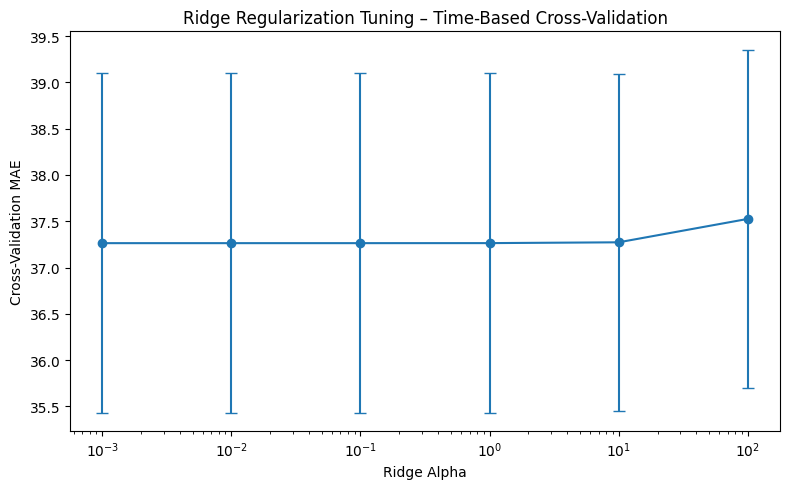

In [508]:
# ============================================================
# W5 CELL 60 — RIDGE CV PLOT
# ============================================================

plt.figure(figsize=(8, 5))

plt.errorbar(
    ridge_cv_results["Alpha"],
    ridge_cv_results["Mean_CV_MAE"],
    yerr=ridge_cv_results["SE"],
    marker="o",
    capsize=4
)

plt.xscale("log")

plt.xlabel("Ridge Alpha")
plt.ylabel("Cross-Validation MAE")

plt.title(
    "Ridge Regularization Tuning – Time-Based Cross-Validation"
)

plt.tight_layout()

plt.savefig(
    "../graphs/w5_ridge_cv_tuning.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

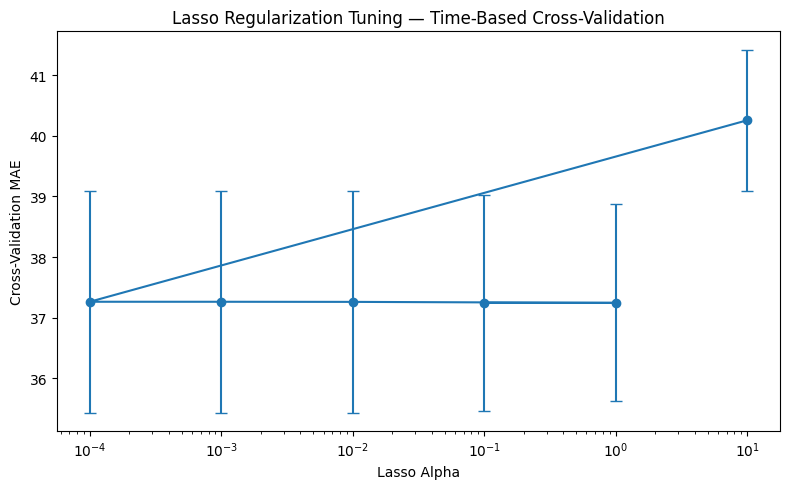

Lasso CV graph saved successfully.


In [509]:
# ============================================================
# W5 CELL 61 — LASSO CV PLOT
# ============================================================

plt.figure(figsize=(8, 5))

plt.errorbar(
    lasso_cv_results["Alpha"],
    lasso_cv_results["Mean_CV_MAE"],
    yerr=lasso_cv_results["SE"],
    marker="o",
    capsize=4
)

plt.xscale("log")

plt.xlabel("Lasso Alpha")
plt.ylabel("Cross-Validation MAE")

plt.title(
    "Lasso Regularization Tuning — Time-Based Cross-Validation"
)

plt.tight_layout()

plt.savefig(
    "../graphs/w5_lasso_cv_tuning.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Lasso CV graph saved successfully.")

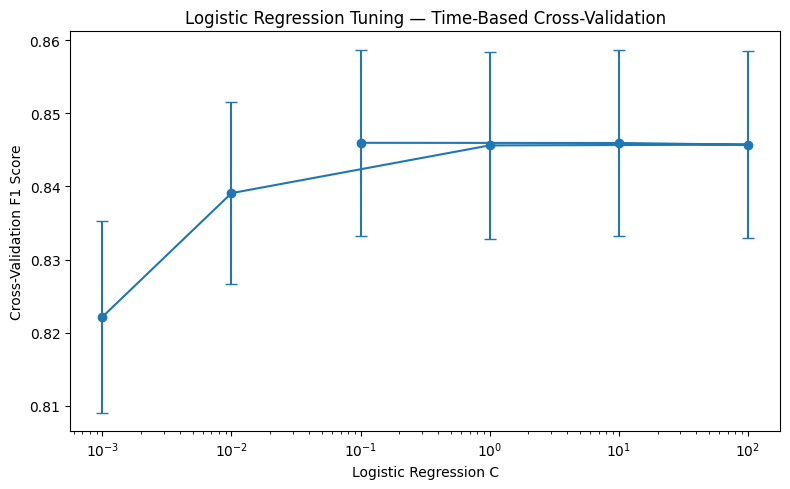

Logistic CV graph saved successfully.


In [510]:
# ============================================================
# W5 CELL 62 — LOGISTIC CV PLOT
# ============================================================

plt.figure(figsize=(8, 5))

plt.errorbar(
    logistic_cv_results["C"],
    logistic_cv_results["Mean_F1"],
    yerr=logistic_cv_results["SE_F1"],
    marker="o",
    capsize=4
)

plt.xscale("log")

plt.xlabel("Logistic Regression C")
plt.ylabel("Cross-Validation F1 Score")

plt.title(
    "Logistic Regression Tuning — Time-Based Cross-Validation"
)

plt.tight_layout()

plt.savefig(
    "../graphs/w5_logistic_cv_tuning.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Logistic CV graph saved successfully.")

In [511]:
# ============================================================
# W5 CELL 63 — FINAL AEROPURE W5 SUMMARY
# ============================================================

print("=" * 75)
print("AEROPURE — WEEK 5 FINAL SUMMARY")
print("=" * 75)

print("\nREGRESSION")
print("-" * 75)

print(
    f"Best Ridge 1-SE alpha : {ridge_alpha_1se}"
)

print(
    f"Ridge MAE             : {final_ridge_mae:.4f}"
)

print(
    f"Ridge RMSE            : {final_ridge_rmse:.4f}"
)

print(
    f"Ridge R²              : {final_ridge_r2:.4f}"
)

print()

print(
    f"Best Lasso 1-SE alpha : {lasso_alpha_1se}"
)

print(
    f"Lasso MAE             : {final_lasso_mae:.4f}"
)

print(
    f"Lasso RMSE            : {final_lasso_rmse:.4f}"
)

print(
    f"Lasso R²              : {final_lasso_r2:.4f}"
)


print("\nCLASSIFICATION")
print("-" * 75)

print(
    f"Best Logistic C       : {logistic_C_1se}"
)

print(
    f"Accuracy              : {final_accuracy:.4f}"
)

print(
    f"Precision             : {final_precision:.4f}"
)

print(
    f"Recall                : {final_recall:.4f}"
)

print(
    f"F1 Score              : {final_f1:.4f}"
)

print(
    f"ROC-AUC               : {final_roc_auc:.4f}"
)

print("\n" + "=" * 75)
print("W5 COMPLETE")
print("=" * 75)

AEROPURE — WEEK 5 FINAL SUMMARY

REGRESSION
---------------------------------------------------------------------------
Best Ridge 1-SE alpha : 100.0
Ridge MAE             : 22.1342
Ridge RMSE            : 40.7133
Ridge R²              : 0.8453

Best Lasso 1-SE alpha : 1.0
Lasso MAE             : 21.9038
Lasso RMSE            : 40.3824
Lasso R²              : 0.8478

CLASSIFICATION
---------------------------------------------------------------------------
Best Logistic C       : 0.01
Accuracy              : 0.9664
Precision             : 0.6897
Recall                : 0.9316
F1 Score              : 0.7926
ROC-AUC               : 0.9896

W5 COMPLETE


In [512]:
# ============================================================
# W5 CELL 64 — SAVE COMPLETE W5 SUMMARY
# ============================================================

w5_summary = pd.DataFrame({
    "Model": [
        "Tuned Ridge — 1-SE",
        "Tuned Lasso — 1-SE",
        "Tuned Logistic — 1-SE"
    ],
    "Hyperparameter": [
        ridge_alpha_1se,
        lasso_alpha_1se,
        logistic_C_1se
    ],
    "MAE": [
        final_ridge_mae,
        final_lasso_mae,
        np.nan
    ],
    "RMSE": [
        final_ridge_rmse,
        final_lasso_rmse,
        np.nan
    ],
    "R2": [
        final_ridge_r2,
        final_lasso_r2,
        np.nan
    ],
    "Accuracy": [
        np.nan,
        np.nan,
        final_accuracy
    ],
    "Precision": [
        np.nan,
        np.nan,
        final_precision
    ],
    "Recall": [
        np.nan,
        np.nan,
        final_recall
    ],
    "F1": [
        np.nan,
        np.nan,
        final_f1
    ],
    "ROC_AUC": [
        np.nan,
        np.nan,
        final_roc_auc
    ]
})

display(w5_summary)

w5_summary.to_csv(
    "../graphs/w5_complete_summary.csv",
    index=False
)

print("Complete W5 summary saved successfully.")

,Model,Hyperparameter,MAE,RMSE,R2,Accuracy,Precision,Recall,F1,ROC_AUC
0,Tuned Ridge — 1-SE,100.00,22.134196,40.713274,0.845266,NaN,NaN,NaN,NaN,NaN
1,Tuned Lasso — 1-SE,1.00,21.903789,40.382361,0.847771,NaN,NaN,NaN,NaN,NaN
2,Tuned Logistic — 1-SE,0.01,NaN,NaN,NaN,0.966363,0.68974,0.931553,0.792614,0.98963


Complete W5 summary saved successfully.


In [513]:
# ============================================================
# W5 CELL 65 — MASTER MODEL RESULTS
# ============================================================

master_results = pd.DataFrame({

    "Model": [
        "W3 OLS",
        "W3 Gradient Descent",
        "W4 Lasso - 11 Features",
        "W4 Engineered Ridge - 16 Features",
        "W4 Engineered Lasso - 16 Features",
        "W5 Tuned Ridge - 1SE",
        "W5 Tuned Lasso - 1SE",
        "W4 Logistic Regression",
        "W5 Tuned Logistic - 1SE"
    ],

    "MAE": [
        ols_mae_w4,
        np.nan,
        lasso_mae,
        ridge_fe_mae,
        lasso_fe_mae,
        final_ridge_mae,
        final_lasso_mae,
        np.nan,
        np.nan
    ],

    "RMSE": [
        ols_rmse_w4,
        np.nan,
        lasso_rmse,
        ridge_fe_rmse,
        lasso_fe_rmse,
        final_ridge_rmse,
        final_lasso_rmse,
        np.nan,
        np.nan
    ],

    "R2": [
        ols_r2_w4,
        np.nan,
        lasso_r2,
        ridge_fe_r2,
        lasso_fe_r2,
        final_ridge_r2,
        final_lasso_r2,
        np.nan,
        np.nan
    ],

    "Accuracy": [
        np.nan,
        np.nan,
        np.nan,
        np.nan,
        np.nan,
        np.nan,
        np.nan,
        accuracy,
        final_accuracy
    ],

    "Precision": [
        np.nan,
        np.nan,
        np.nan,
        np.nan,
        np.nan,
        np.nan,
        np.nan,
        precision,
        final_precision
    ],

    "Recall": [
        np.nan,
        np.nan,
        np.nan,
        np.nan,
        np.nan,
        np.nan,
        np.nan,
        recall,
        final_recall
    ],

    "F1": [
        np.nan,
        np.nan,
        np.nan,
        np.nan,
        np.nan,
        np.nan,
        np.nan,
        f1,
        final_f1
    ],

    "ROC_AUC": [
        np.nan,
        np.nan,
        np.nan,
        np.nan,
        np.nan,
        np.nan,
        np.nan,
        roc_auc,
        final_roc_auc
    ]
})


print("=" * 75)
print("AEROPURE — MASTER MODEL RESULTS")
print("=" * 75)

display(master_results)


master_results.to_csv(
    "../graphs/aeropure_master_model_results.csv",
    index=False
)

print("\nMaster results saved successfully.")

AEROPURE — MASTER MODEL RESULTS


,Model,MAE,RMSE,R2,Accuracy,Precision,Recall,F1,ROC_AUC
0,W3 OLS,25.694745,42.475218,0.833065,NaN,NaN,NaN,NaN,NaN
1,W3 Gradient Descent,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,W4 Lasso - 11 Features,25.688423,42.459937,0.833186,NaN,NaN,NaN,NaN,NaN
3,W4 Engineered Ridge - 16 Features,22.134959,40.727729,0.845156,NaN,NaN,NaN,NaN,NaN
4,W4 Engineered Lasso - 16 Features,22.128465,40.715327,0.845250,NaN,NaN,NaN,NaN,NaN
5,W5 Tuned Ridge - 1SE,22.134196,40.713274,0.845266,NaN,NaN,NaN,NaN,NaN
6,W5 Tuned Lasso - 1SE,21.903789,40.382361,0.847771,NaN,NaN,NaN,NaN,NaN
7,W4 Logistic Regression,NaN,NaN,NaN,0.969090,0.70632,0.940594,0.806794,0.991235
8,W5 Tuned Logistic - 1SE,NaN,NaN,NaN,0.966363,0.68974,0.931553,0.792614,0.989630



Master results saved successfully.


In [514]:
# ============================================================
# EXPORT DATA FOR W6
# ============================================================

train_fe.to_csv("../data/train_fe_w6.csv", index=False)
test_fe.to_csv("../data/test_fe_w6.csv", index=False)

print("W6 training data saved:", train_fe.shape)
print("W6 test data saved:", test_fe.shape)

W6 training data saved: (15636, 22)
W6 test data saved: (8681, 22)
